In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lo_tools import Lfun
Ldir = Lfun.Lstart()
from scipy.stats import ks_2samp

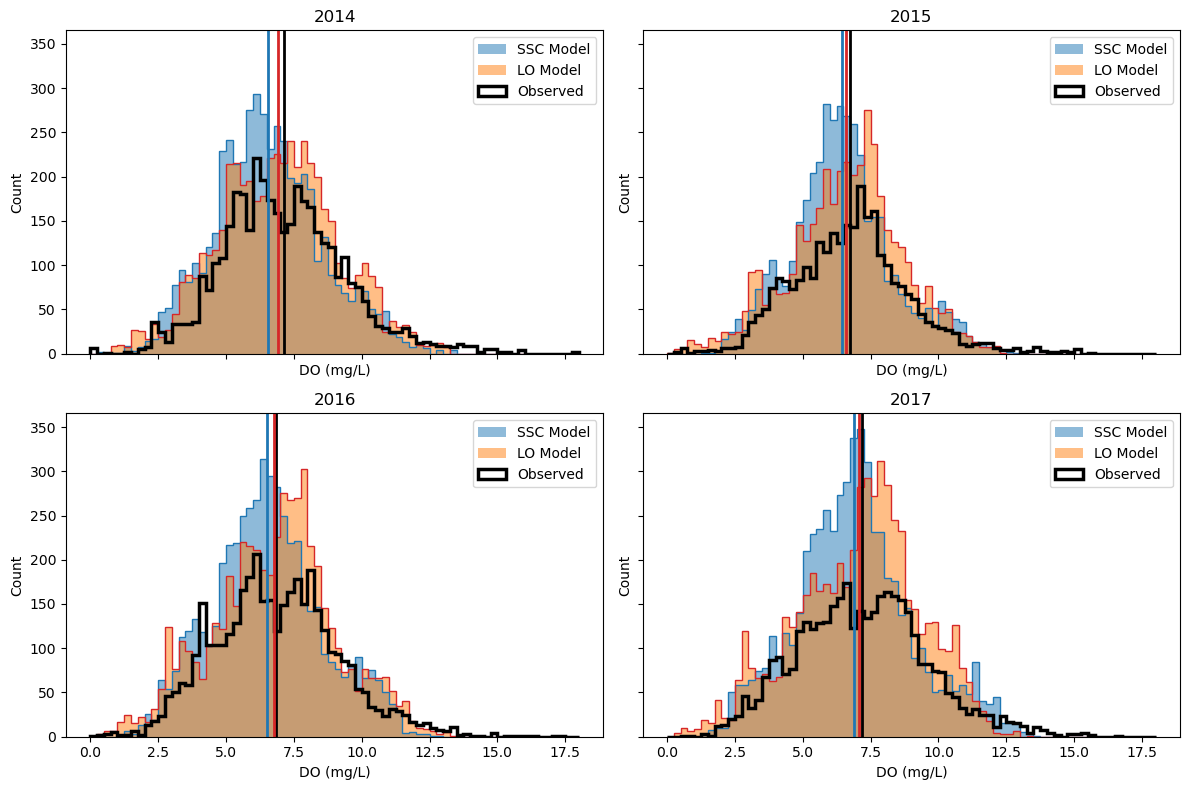

In [6]:
years = ['2014', '2015', '2016', '2017']

in_dir = Ldir['parent'] / 'LO_output' / 'obsmod'

vn = 'DO'

obs = {}
ssc = {}
lo = {}

# --------------------
# Load + convert
# --------------------
for year in years:

    in_fn = (
        in_dir /
        f'combined_bottle_{year}_cas7_t1_x11ab_ssc.pkl'
    )

    df_dict = pd.read_pickle(in_fn)

    obs[year] = df_dict['obs'][vn].to_numpy() * 0.032
    ssc[year] = df_dict['ssc'][vn].to_numpy() * 0.032
    lo[year] = df_dict['cas7_t1_x11ab'][vn].to_numpy() * 0.032

# --------------------
# Shared bins
# --------------------
all_vals = np.concatenate([
    np.concatenate([obs[y], ssc[y], lo[y]])
    for y in years
])

bins = np.arange(
    np.floor(np.nanmin(all_vals)),
    np.ceil(np.nanmax(all_vals)) + 0.25,
    0.25
)

# --------------------
# Plot
# --------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

axes = axes.ravel()

for i, year in enumerate(years):
    ax = axes[i]

    ax.hist(
        ssc[year],
        bins=bins,
        alpha=0.5,
        label='SSC Model',
        density=False
    )
    
    
    ax.hist(
        lo[year],
        bins=bins,
        alpha=0.5,
        label='LO Model',
        density=False
    )
    
    # add thin line around histogram bars
    ax.hist(
        ssc[year],
        bins=bins,
        histtype='step',
        color='tab:blue',
        linewidth=1,
    )
    
    ax.hist(
        lo[year],
        bins=bins,
        histtype='step',
        color='tab:red',
        linewidth=1,
    )
    
    ax.hist(
        obs[year],
        bins=bins,
        histtype='step',
        label='Observed',
        linewidth=2.5,
        color= 'black'
    )

    
    # Mean lines
    ax.axvline(np.nanmean(obs[year]), color='black', linestyle='-', linewidth=2)
    ax.axvline(np.nanmean(ssc[year]), color='tab:blue', linestyle='-', linewidth=2)
    ax.axvline(np.nanmean(lo[year]),  color='tab:red', linestyle='-', linewidth=2)

    ax.set_title(year)
    ax.set_xlabel('DO (mg/L)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
years = ['2014', '2015', '2016', '2017']

ks_ssc = {}
ks_lo = {}

for year in years:

    # remove NaNs (IMPORTANT for KS test)
    obs_y = obs[year]
    ssc_y = ssc[year]
    lo_y  = lo[year]

    m1 = np.isfinite(obs_y) & np.isfinite(ssc_y)
    m2 = np.isfinite(obs_y) & np.isfinite(lo_y)

    ks_ssc[year] = ks_2samp(obs_y[m1], ssc_y[m1])
    ks_lo[year]  = ks_2samp(obs_y[m2], lo_y[m2])

    print(
        f"{year}:\n"
        f"  KS Obs vs SSC: D={ks_ssc[year].statistic:.3f}, p={ks_ssc[year].pvalue:.3e}\n"
        f"  KS Obs vs LO : D={ks_lo[year].statistic:.3f}, p={ks_lo[year].pvalue:.3e}\n"
    )

2014:
  KS Obs vs SSC: D=0.128, p=3.291e-28
  KS Obs vs LO : D=0.085, p=8.357e-13

2015:
  KS Obs vs SSC: D=0.134, p=7.141e-23
  KS Obs vs LO : D=0.097, p=4.340e-12

2016:
  KS Obs vs SSC: D=0.095, p=7.203e-16
  KS Obs vs LO : D=0.081, p=1.452e-11

2017:
  KS Obs vs SSC: D=0.100, p=6.545e-17
  KS Obs vs LO : D=0.080, p=4.278e-11



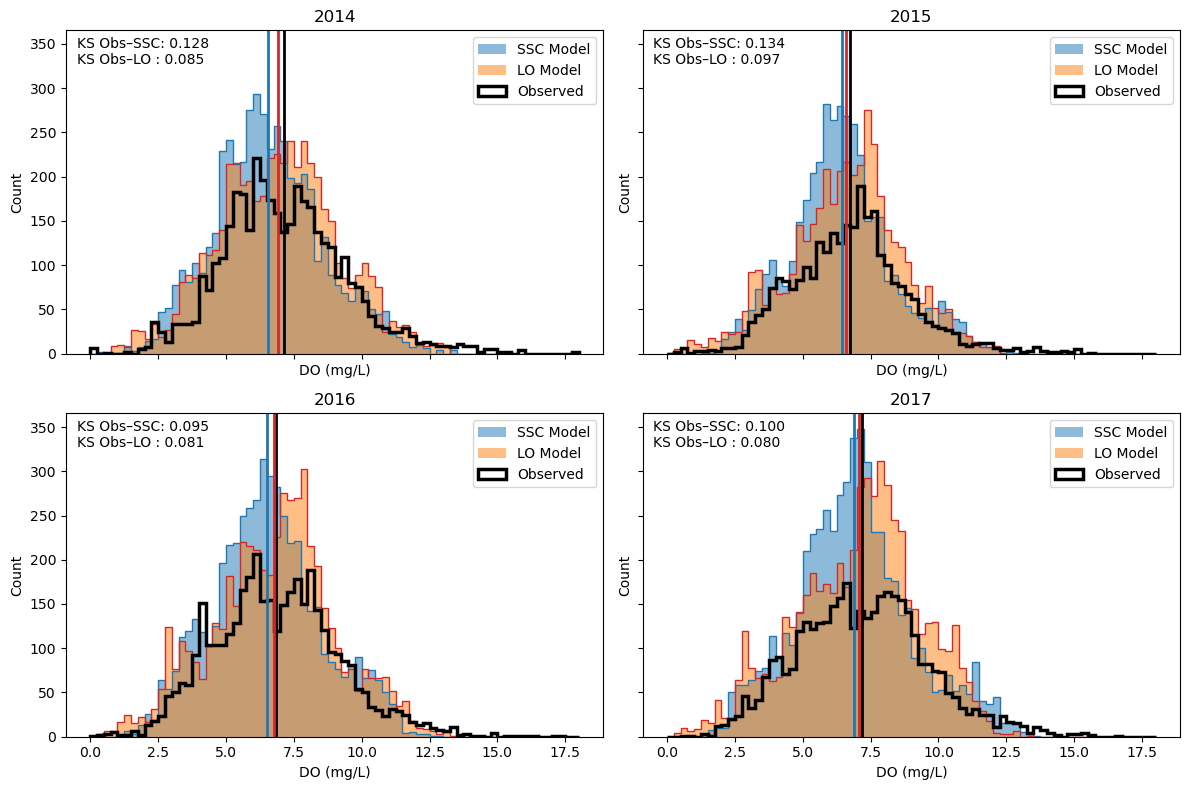

In [11]:
# with KS test

from scipy.stats import ks_2samp
import numpy as np
import matplotlib.pyplot as plt

ks_ssc = {}
ks_lo = {}

# --------------------
# KS computation (same as before)
# --------------------
for year in years:

    obs_y = obs[year]
    ssc_y = ssc[year]
    lo_y  = lo[year]

    m1 = np.isfinite(obs_y) & np.isfinite(ssc_y)
    m2 = np.isfinite(obs_y) & np.isfinite(lo_y)

    ks_ssc[year] = ks_2samp(obs_y[m1], ssc_y[m1])
    ks_lo[year]  = ks_2samp(obs_y[m2], lo_y[m2])

# --------------------
# Plot
# --------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, year in enumerate(years):
    ax = axes[i]

    # SSC
    ax.hist(
        ssc[year],
        bins=bins,
        alpha=0.5,
        label='SSC Model',
        density=False
    )

    ax.hist(
        lo[year],
        bins=bins,
        alpha=0.5,
        label='LO Model',
        density=False
    )

    # outlines
    ax.hist(ssc[year], bins=bins, histtype='step',
            color='tab:blue', linewidth=1)
    ax.hist(lo[year], bins=bins, histtype='step',
            color='tab:red', linewidth=1)
    ax.hist(obs[year], bins=bins, histtype='step',
            color='black', linewidth=2.5, label='Observed')

    # mean lines
    ax.axvline(np.nanmean(obs[year]), color='black', linewidth=2)
    ax.axvline(np.nanmean(ssc[year]), color='tab:blue', linewidth=2)
    ax.axvline(np.nanmean(lo[year]),  color='tab:red', linewidth=2)

    # --------------------
    # KS annotation box
    # --------------------
    text = (
        f"KS Obs–SSC: {ks_ssc[year].statistic:.3f}\n"
        f"KS Obs–LO : {ks_lo[year].statistic:.3f}"
    )

    ax.text(
        0.02, 0.98,
        text,
        transform=ax.transAxes,
        va='top',
        fontsize=10,
        )

    ax.set_title(year)
    ax.set_xlabel('DO (mg/L)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

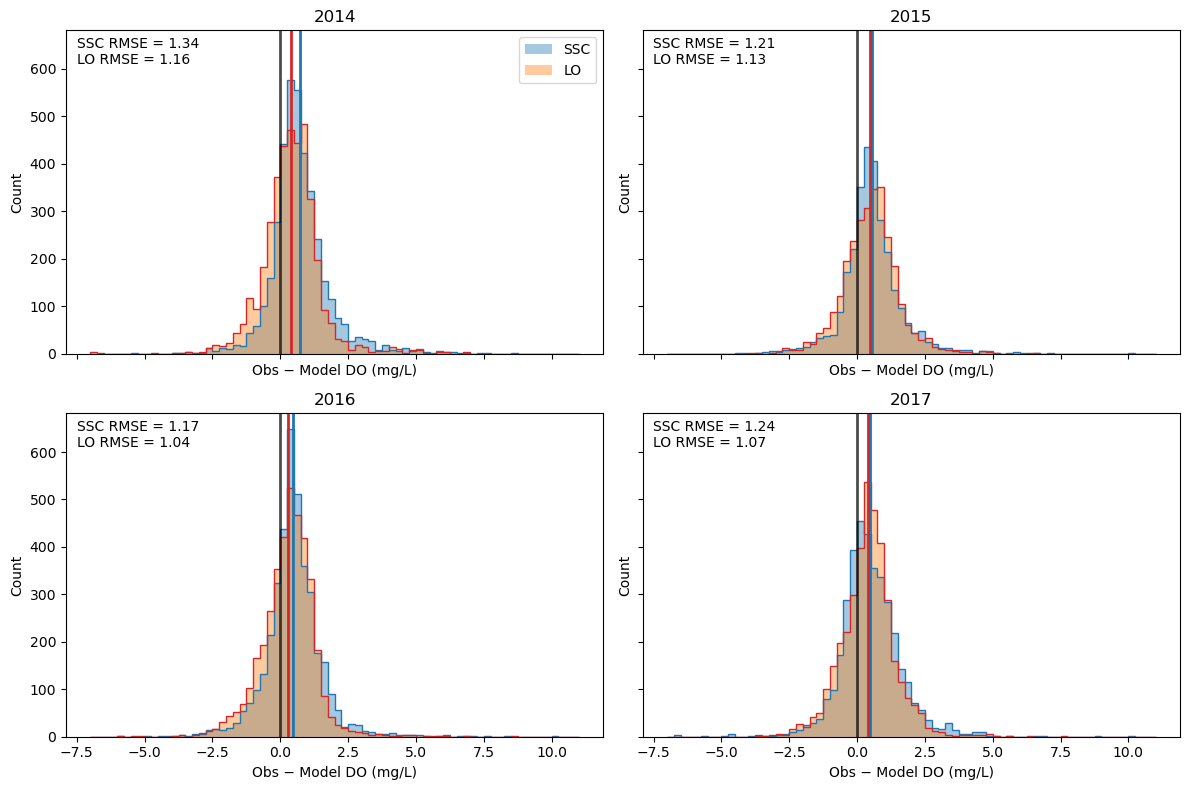

In [14]:
years = ['2014', '2015', '2016', '2017']

in_dir = Ldir['parent'] / 'LO_output' / 'obsmod'

vn = 'DO'

obs = {}
ssc = {}
lo = {}

# --------------------
# Load + convert
# --------------------
for year in years:

    in_fn = (
        in_dir /
        f'combined_bottle_{year}_cas7_t1_x11ab_ssc.pkl'
    )

    df_dict = pd.read_pickle(in_fn)

    obs[year] = df_dict['obs'][vn].to_numpy() * 0.032
    ssc[year] = df_dict['ssc'][vn].to_numpy() * 0.032
    lo[year]  = df_dict['cas7_t1_x11ab'][vn].to_numpy() * 0.032

# --------------------
# Errors
# --------------------
err_ssc = {}
err_lo = {}

for year in years:
    err_ssc[year] = obs[year] - ssc[year]
    err_lo[year] = obs[year] - lo[year]

# --------------------
# Common bins
# --------------------
all_errors = np.concatenate([
    err_ssc[y][np.isfinite(err_ssc[y])]
    for y in years
] + [
    err_lo[y][np.isfinite(err_lo[y])]
    for y in years
])

bins = np.arange(
    np.floor(np.nanmin(all_errors)),
    np.ceil(np.nanmax(all_errors)) + 0.25,
    0.25
)

# --------------------
# Plot
# --------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex=True,
    sharey=True
)

axes = axes.ravel()

for i, year in enumerate(years):

    ax = axes[i]

    # SSC
    ax.hist(
        err_ssc[year],
        bins=bins,
        alpha=0.4,
        label='SSC'
    )
    
    ax.hist(
        err_ssc[year],
        bins=bins,
        histtype='step',
        color='tab:blue',
        linewidth=1,
    )

    # LO
    ax.hist(
        err_lo[year],
        bins=bins,
        alpha=0.4,
        label='LO'
    )
    
    ax.hist(
        err_lo[year],
        bins=bins,
        histtype='step',
        color='tab:red',
        linewidth=1,
    )

    # Means
    ax.axvline(
        np.nanmean(err_ssc[year]),
        linestyle='-',
        color='tab:blue',
        linewidth=2
    )

    ax.axvline(
        np.nanmean(err_lo[year]),
        linestyle='-',
        color='tab:red',
        linewidth=2
    )

    # Zero-error reference
    ax.axvline(
        0,
        color='k',
        linewidth=2,
        alpha=0.7
    )

    ax.set_title(year)
    ax.set_xlabel('Obs − Model DO (mg/L)')
    ax.set_ylabel('Count')

    # RMSE annotations
    rmse_ssc = np.sqrt(np.nanmean(err_ssc[year]**2))
    rmse_lo = np.sqrt(np.nanmean(err_lo[year]**2))

    ax.text(
        0.02, 0.98,
        f'SSC RMSE = {rmse_ssc:.2f}\nLO RMSE = {rmse_lo:.2f}',
        transform=ax.transAxes,
        va='top'
    )

axes[0].legend()

plt.tight_layout()
plt.show()

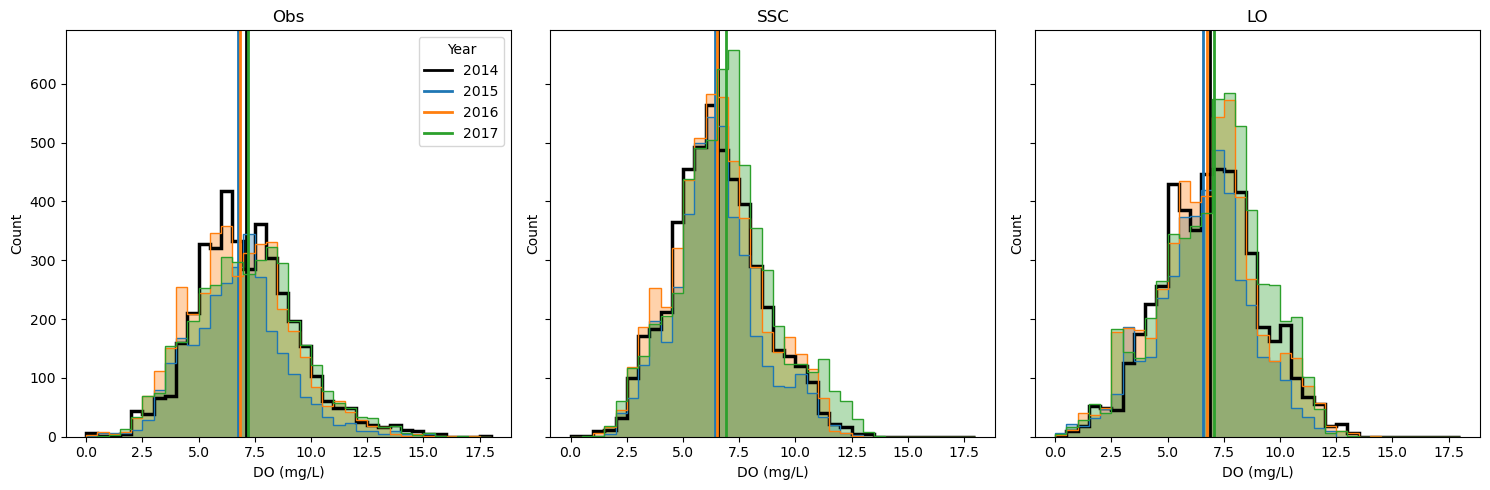

In [3]:
years = ['2014', '2015', '2016', '2017']

in_dir = Ldir['parent'] / 'LO_output' / 'obsmod'

vn = 'DO'

obs = {}
ssc = {}
lo = {}

# --------------------
# Load + convert
# --------------------
for year in years:

    in_fn = (
        in_dir /
        f'combined_bottle_{year}_cas7_t1_x11ab_ssc.pkl'
    )

    df_dict = pd.read_pickle(in_fn)

    obs[year] = df_dict['obs'][vn].to_numpy() * 0.032
    ssc[year] = df_dict['ssc'][vn].to_numpy() * 0.032
    lo[year]  = df_dict['cas7_t1_x11ab'][vn].to_numpy() * 0.032

# --------------------
# Shared bins across all data
# --------------------
all_vals = np.concatenate([
    obs[y] for y in years
] + [
    ssc[y] for y in years
] + [
    lo[y] for y in years
])

bin_width = 0.5

bins = np.arange(
    np.floor(np.nanmin(all_vals)),
    np.ceil(np.nanmax(all_vals)) + bin_width,
    bin_width
)

colors = {
    '2014': 'black',
    '2015': 'tab:blue',
    '2016': 'tab:orange',
    '2017': 'tab:green'
}

# --------------------
# Plot: panels = dataset type
# --------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = {
    "Obs": obs,
    "SSC": ssc,
    "LO": lo
}

for ax, (name, data) in zip(axes, datasets.items()):

    for year in years:
        
        if year == '2014':
            # outline only
            ax.hist(
                data[year],
                bins=bins,
                histtype='step',
                linewidth=2.5,
                color='black',
                label=year
            )

            ax.axvline(
                np.nanmean(data[year]),
                color='black',
                linestyle='-',
                linewidth=2
            )

        else:
            ax.hist(
                data[year],
                bins=bins,
                alpha=0.35,
                color=colors[year],
                label=year
            )
            
            ax.hist(
                data[year],
                bins=bins,
                histtype='step',
                color=colors[year],
                linewidth=1,
    )

            ax.axvline(
                np.nanmean(data[year]),
                color=colors[year],
                linestyle='-',
                linewidth=2
            )

    ax.set_title(name)
    ax.set_xlabel('DO (mg/L)')
    ax.set_ylabel('Count')

# single legend for years
handles = [
    plt.Line2D([0], [0], color=colors[y], lw=2, label=y)
    for y in years
]
axes[0].legend(handles=handles, title="Year")

plt.tight_layout()
plt.show()

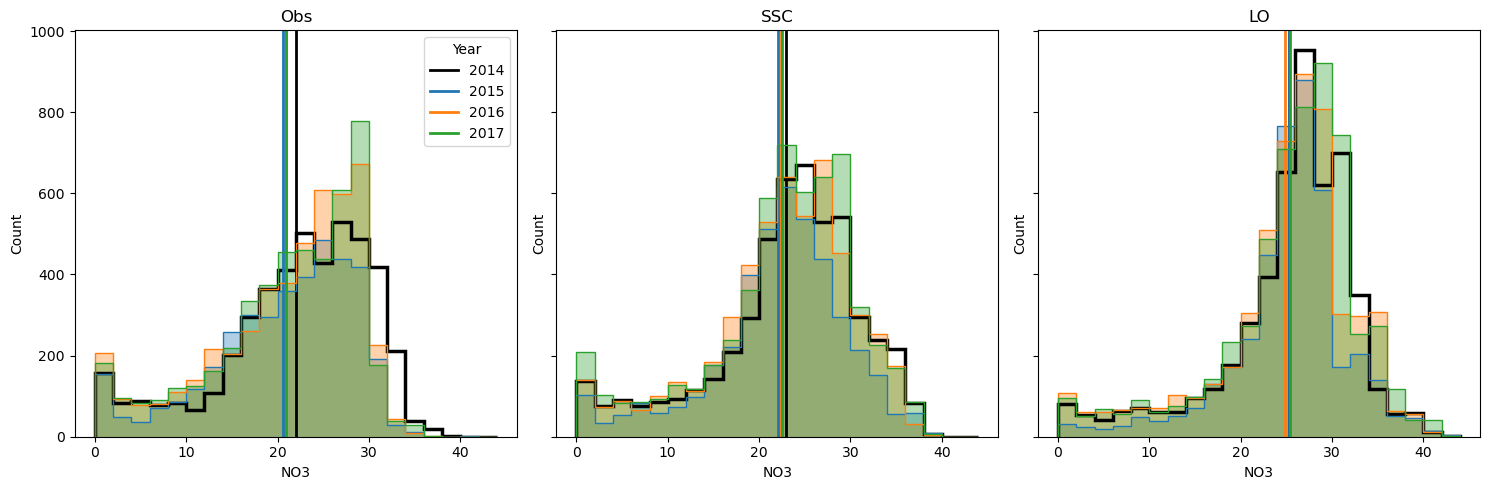

In [4]:
years = ['2014', '2015', '2016', '2017']

in_dir = Ldir['parent'] / 'LO_output' / 'obsmod'

vn = 'NO3'

obs = {}
ssc = {}
lo = {}

# --------------------
# Load + convert
# --------------------
for year in years:

    in_fn = (
        in_dir /
        f'combined_bottle_{year}_cas7_t1_x11ab_ssc.pkl'
    )

    df_dict = pd.read_pickle(in_fn)

    obs[year] = df_dict['obs'][vn].to_numpy() 
    ssc[year] = df_dict['ssc'][vn].to_numpy() 
    lo[year]  = df_dict['cas7_t1_x11ab'][vn].to_numpy() 

# --------------------
# Shared bins across all data
# --------------------
all_vals = np.concatenate([
    obs[y] for y in years
] + [
    ssc[y] for y in years
] + [
    lo[y] for y in years
])

bin_width = 2

bins = np.arange(
    np.floor(np.nanmin(all_vals)),
    np.ceil(np.nanmax(all_vals)) + bin_width,
    bin_width
)

colors = {
    '2014': 'black',
    '2015': 'tab:blue',
    '2016': 'tab:orange',
    '2017': 'tab:green'
}

# --------------------
# Plot: panels = dataset type
# --------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = {
    "Obs": obs,
    "SSC": ssc,
    "LO": lo
}

for ax, (name, data) in zip(axes, datasets.items()):

    for year in years:
        
        if year == '2014':
            # outline only
            ax.hist(
                data[year],
                bins=bins,
                histtype='step',
                linewidth=2.5,
                color='black',
                label=year
            )

            ax.axvline(
                np.nanmean(data[year]),
                color='black',
                linestyle='-',
                linewidth=2
            )

        else:
            ax.hist(
                data[year],
                bins=bins,
                alpha=0.35,
                color=colors[year],
                label=year
            )
            
            ax.hist(
                data[year],
                bins=bins,
                histtype='step',
                color=colors[year],
                linewidth=1
            )

            ax.axvline(
                np.nanmean(data[year]),
                color=colors[year],
                linestyle='-',
                linewidth=2
            )

    ax.set_title(name)
    ax.set_xlabel('NO3')
    ax.set_ylabel('Count')

# single legend for years
handles = [
    plt.Line2D([0], [0], color=colors[y], lw=2, label=y)
    for y in years
]
axes[0].legend(handles=handles, title="Year")

plt.tight_layout()
plt.show()